In [10]:
import pandas as pd
from fredapi import Fred
import matplotlib.pyplot as plt
import seaborn as sns
from credentials import fred_api_key
import numpy as np
import matplotlib.pyplot as plt
from nelson_siegel_svensson.calibrate import calibrate_ns_ols



In [ ]:
# Initialize the FRED API with your key
fred = Fred(api_key=fred_api_key) # Replace my APIKEY with "YOUR_API_KEY"

# List of Treasury yield series IDs
series_ids = ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', \
              'DGS7', 'DGS10', 'DGS20', 'DGS30']

# Function to get data for a single series
def get_yield_data(series_id):
    data = fred.get_series(series_id, observation_start="1975-01-01", observation_end="2026-05-01")
    return data

# Get data for all series
yields_dict = {series_id: get_yield_data(series_id) for series_id in series_ids}

# Combine into a single DataFrame
yields = pd.DataFrame(yields_dict)

# Rename columns for clarity
yields.columns = ['1 Month', '3 Month', '6 Month', '1 Year', '2 Year', '3 Year', '5 Year', \
                  '7 Year', '10 Year', '20 Year', '30 Year']
yields.to_pickle("US treasury rates from 1975 to 2026.pkl")


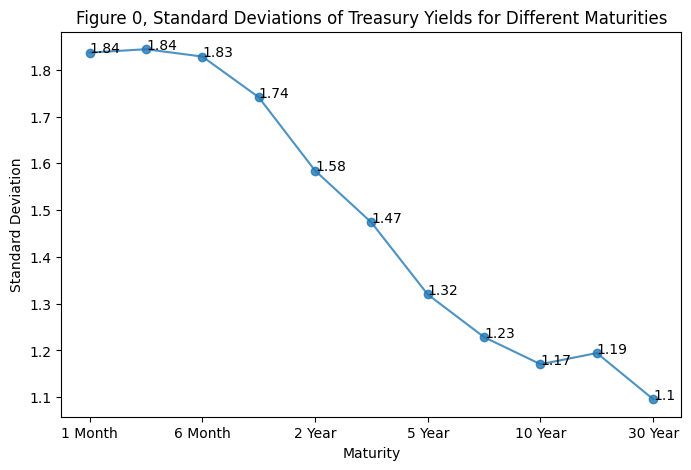

In [5]:
yields = yields.dropna()
y_std = yields.std()
fig, ax = plt.subplots()
y_std.plot(figsize = (8,5),marker='o', title='Figure 0, Standard Deviations of Treasury Yields for Different Maturities', alpha=0.8) # Plot standard deviations of yields of different maturies
plt.xlabel("Maturity")
plt.ylabel("Standard Deviation")
for i in range(len(y_std)):
    ax.annotate(str(round(y_std.iloc[i],2)),xy=(i,y_std.iloc[i]))
plt.show()


### **Nelson Siegel Model**
The **Nelson Siegel model (NS model)** is a popular model for describing the relationship between maturity and yield (Svensson). Here is the formula for the model:

$$y(t)=\beta_{0}+\beta_{1}\left( \frac{1-e^{-\lambda t}}{\lambda t} \right)+\beta_{2}\left( \frac{1-e^{^{-\lambda t}}}{\lambda t}-e^{-\lambda t} \right)+\epsilon$$
<br>
$\beta_{0},\beta_{1},\beta_{2}$ are the parameters to be estimated. $t$ is the time to maturity and $\lambda$ is the decay rate. The decay rate is between 0 and 1. $\beta_{0}$ is used to describe the level of the yield curve. $\beta_{1}$ is used to describe the slope of the yield curve and $\beta_{2}$ is used to describe the shape of the yield curve. For this reason, we also call the NS model a **yield curve factor model**. The NS model decomposes the yield curve into three elements as described above.
<br>
How does the decay rate work? The smaller the decay rate, the slower the curve decays. The larger the decay rate, the faster the curve decays. The decay rate shows how fast the yield will converge to the long-term average.
<br>
With the NS model's simple structure, we can use different elements in the model to describe different yield curve behaviors. Once we have an estimated NS model, we can use the model to predict the action of future interest rate moves (Pape).
<br>
Let's use the Nelson Siegel Sevensson package from Python to demonstrate the NS model.
<br>
<br>


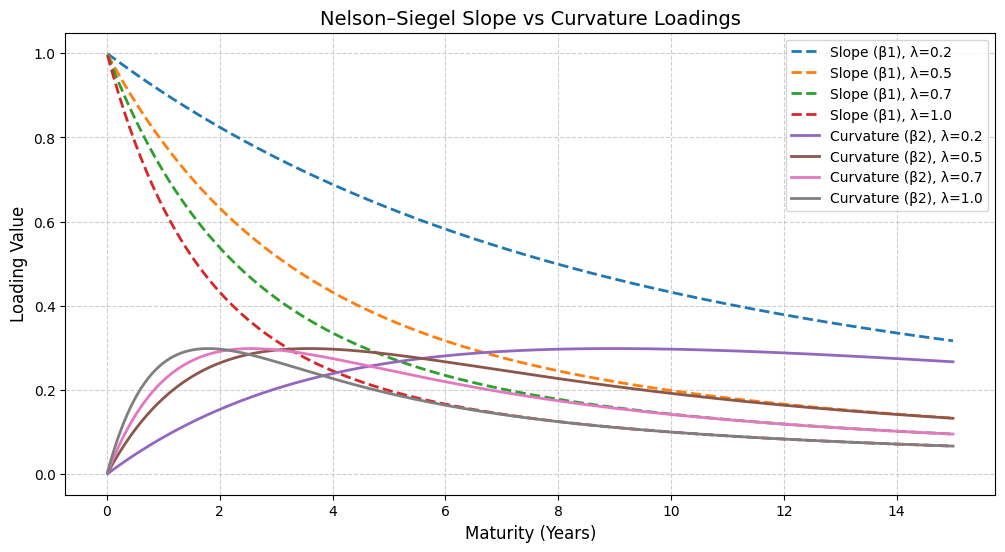

In [8]:

## Understand the impact of lambda on the curvature and slope coefficients in the NS model

# Define maturities (in years)
t = np.linspace(0.01, 15, 300)

# Define a list of lambda values to test
lambdas = [0.2, 0.5, 0.7, 1.0]

plt.figure(figsize=(12, 6))

# Plot slope loadings
for lam in lambdas:
    f1 = (1 - np.exp(-lam * t)) / (lam * t)
    plt.plot(t, f1, linestyle="--", linewidth=2,
             label=f"Slope (β1), λ={lam}")

# Plot curvature loadings
for lam in lambdas:
    f2 = (1 - np.exp(-lam * t)) / (lam * t) - np.exp(-lam * t)
    plt.plot(t, f2, linestyle="-", linewidth=2,
             label=f"Curvature (β2), λ={lam}")

# Customize the plot
plt.title("Nelson–Siegel Slope vs Curvature Loadings", fontsize=14)
plt.xlabel("Maturity (Years)", fontsize=12)
plt.ylabel("Loading Value", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()



NelsonSiegelCurve(beta0=np.float64(2.6376805011083615), beta1=np.float64(-1.1025855357123264), beta2=np.float64(-1.1406474779544136), tau=np.float64(4.750012469139109))


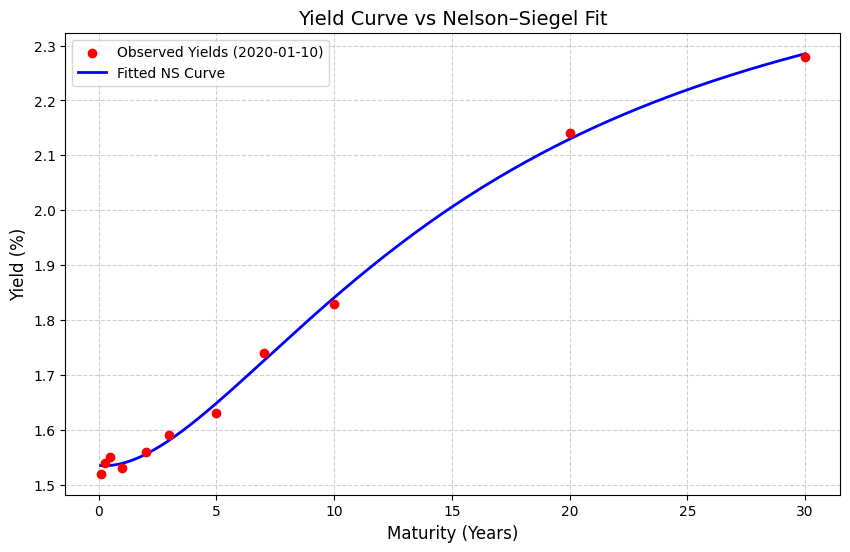

In [12]:
# Create maturity and yield variables in array 
# Example maturities (years)
t = np.array([0.08333, 0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30])

# Example yields (replace with your actual yields DataFrame row)
y = np.array(yields.loc["2020-01-10"])

# Fit Nelson-Siegel model using OLS calibration
curve, status = calibrate_ns_ols(t, y, tau0=1.0)  # tau0 is initial guess for λ
assert status.success
print(curve)  # shows estimated β0, β1, β2, λ

# Generate fitted curve values
t_hat = np.linspace(0.08333, 30, 200)
y_hat = curve(t_hat)

# Plot observed yields vs fitted NS curve
plt.figure(figsize=(10, 6))
plt.scatter(t, y, color="red", label="Observed Yields (2020-01-10)", zorder=5)
plt.plot(t_hat, y_hat, color="blue", linewidth=2, label="Fitted NS Curve")
plt.xlabel("Maturity (Years)", fontsize=12)
plt.ylabel("Yield (%)", fontsize=12)
plt.title("Yield Curve vs Nelson–Siegel Fit", fontsize=14)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


In [ ]:


# Define maturities corresponding to your columns
maturities = np.array([0.08333, 0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30])

# Restrict yields DataFrame to the desired time window
yields_subset = yields.loc["2001-01-01":"2026-05-01"].dropna()

# Storage for parameters
params = []

# Loop through each date and fit NS model
for date, row in yields_subset.iterrows():
    y = row.values
    try:
        curve, status = calibrate_ns_ols(maturities, y, tau0=1.0)
        if status.success:
            params.append([date, curve.beta0, curve.beta1, curve.beta2, curve.tau])
    except Exception:
        # Skip problematic dates
        continue

# Convert results to DataFrame
params_df = pd.DataFrame(params, columns=["Date", "Beta0", "Beta1", "Beta2", "Lambda"])
params_df.set_index("Date", inplace=True)



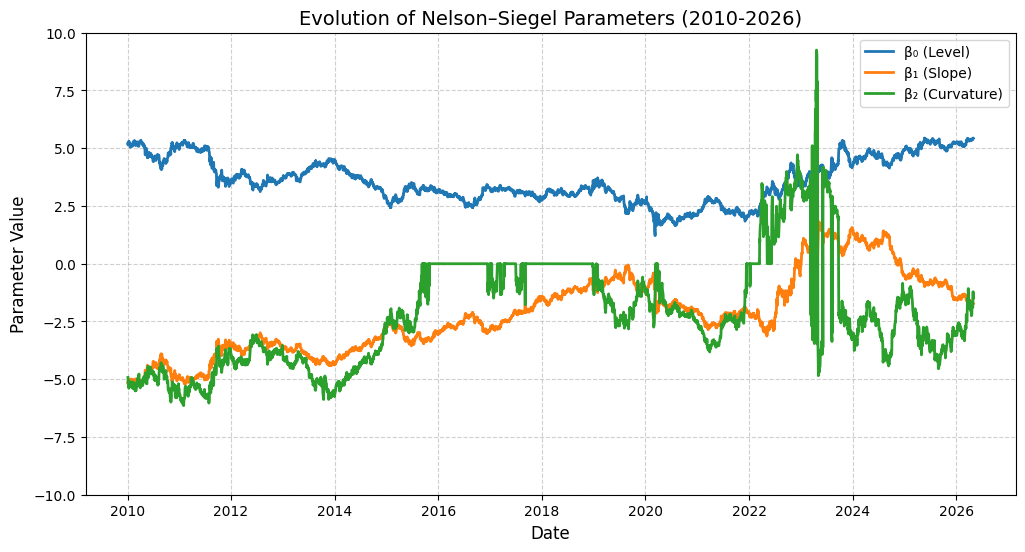

In [27]:
params_df_post_2010=params_df[params_df.index>'2010-01-01']
# Plot the evolution of Beta0, Beta1, Beta2
plt.figure(figsize=(12, 6))
plt.plot(params_df_post_2010.index, params_df_post_2010["Beta0"], label="β₀ (Level)", linewidth=2)
plt.plot(params_df_post_2010.index, params_df_post_2010["Beta1"], label="β₁ (Slope)", linewidth=2)
plt.plot(params_df_post_2010.index, params_df_post_2010["Beta2"], label="β₂ (Curvature)", linewidth=2)
plt.title("Evolution of Nelson–Siegel Parameters (2010-2026)", fontsize=14)
plt.xlabel("Date", fontsize=12)
# Set y-axis limit
plt.ylim(-10, 10) 
plt.ylabel("Parameter Value", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()
